# Actividad opcional: EDA básico con Heart Disease

Notebook resuelta a partir de la clase de carga y exploración de datos, usando el dataset Heart Disease de UCI.

## Objetivo

Realizar un EDA básico siguiendo la estructura vista en clase: estadística descriptiva, tipos de variables, relaciones entre variables y al menos tres gráficos.

## Dataset elegido

Voy a trabajar con el dataset **Heart Disease** de UCI, usando el archivo procesado de Cleveland que dejé en `dataset_tp/heart_disease_cleveland.csv`. Este subset es el más usado en ejemplos de clase y tiene 303 filas y 14 variables.

| Variable   | Descripción |
| ---------- | --------------------------------------------------------------------- |
| `age`      | Edad del paciente (en años) |
| `sex`      | Sexo (1 = masculino, 0 = femenino) |
| `cp`       | Tipo de dolor de pecho (1, 2, 3, 4) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol`     | Colesterol sérico (mg/dl) |
| `fbs`      | Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no) |
| `restecg`  | Resultados electrocardiográficos en reposo (0, 1, 2) |
| `thalach`  | Frecuencia cardíaca máxima alcanzada |
| `exang`    | Angina inducida por ejercicio (1 = sí, 0 = no) |
| `oldpeak`  | Depresión del ST inducida por ejercicio |
| `slope`    | Pendiente del segmento ST (1, 2, 3) |
| `ca`       | Número de vasos principales coloreados por fluoroscopía (0-3) |
| `thal`     | Resultado del test de talio (3, 6, 7) |
| `num`      | Diagnóstico de enfermedad cardíaca (0 = sin, 1-4 = severidad) |

## 1. Librerías y carga de datos

Primero importamos las librerías de trabajo y leemos el CSV desde la carpeta `dataset_tp` del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
 
sns.set_theme(style="whitegrid", palette="deep")

path = "../dataset_tp/heart_disease_cleveland.csv"
df = pd.read_csv(path, na_values=["?"])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Funciones auxiliares (helper functions)

In [2]:
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis_val = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetria: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis_val:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='+-1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

In [3]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [4]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorias que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorias presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    print(f"Frecuencias de cada categoria en la variable '{columna}':\n{freq_tabla}\n")

In [5]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribucion de "{column}"')
    ax.axis('equal')

In [6]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')
    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 2. Vista general del dataset

Acá revisamos cuántas filas y columnas tiene, qué tipos de variables hay y si existen valores faltantes o duplicados.

In [7]:
print(f"Filas y columnas: {df.shape}")
df.info()

Filas y columnas: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 3. Estadistica descriptiva y tipos de variables

Con el resumen anterior podemos ver medidas centrales, dispersion y como quedan clasificadas las columnas del dataset.

In [9]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
df["target"] = df["num"].apply(lambda value: "Con enfermedad" if value > 0 else "Sin enfermedad")

tipos = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
})

duplicados = df.duplicated().sum()
print(f"Cantidad de duplicados: {duplicados}")
tipos

Cantidad de duplicados: 0


,tipo,nulos,porcentaje_nulos
age,float64,0,0.00
sex,float64,0,0.00
cp,float64,0,0.00
trestbps,float64,0,0.00
chol,float64,0,0.00
fbs,float64,0,0.00
restecg,float64,0,0.00
thalach,float64,0,0.00
exang,float64,0,0.00
oldpeak,float64,0,0.00


### 3.1 Clasificacion de tipos de variables

In [10]:
numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_nominales = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print("Variables numericas:", numericas)
print("Variables categoricas nominales:", cat_nominales)
print("Variable objetivo: target (categorica nominal)")

Variables numericas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Variables categoricas nominales: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Variable objetivo: target (categorica nominal)


### 3.2 Estadistica descriptiva de variables numericas

#### Medidas de tendencia central: media, mediana y moda

In [11]:
for col in numericas:
    media = df[col].mean()
    mediana = df[col].median()
    moda = df[col].mode()[0]
    print(f"Variable: {col}")
    print(f"  Media:   {media:.2f}")
    print(f"  Mediana: {mediana:.2f}")
    print(f"  Moda:    {moda:.2f}\n")

Variable: age
  Media:   54.44
  Mediana: 56.00
  Moda:    58.00

Variable: trestbps
  Media:   131.69
  Mediana: 130.00
  Moda:    120.00

Variable: chol
  Media:   246.69
  Mediana: 241.00
  Moda:    197.00

Variable: thalach
  Media:   149.61
  Mediana: 153.00
  Moda:    162.00

Variable: oldpeak
  Media:   1.04
  Mediana: 0.80
  Moda:    0.00

Variable: ca
  Media:   0.67
  Mediana: 0.00
  Moda:    0.00



#### Medidas de dispersion: varianza y desviacion estandar

In [12]:
for col in numericas:
    media = df[col].mean()
    var = df[col].var()
    std = df[col].std()
    print(f"Variable: {col}")
    print(f"  Media: {media:.2f}, Varianza: {var:.2f}, Desv. Estandar: {std:.2f}\n")

Variable: age
  Media: 54.44, Varianza: 81.70, Desv. Estandar: 9.04

Variable: trestbps
  Media: 131.69, Varianza: 309.75, Desv. Estandar: 17.60

Variable: chol
  Media: 246.69, Varianza: 2680.85, Desv. Estandar: 51.78

Variable: thalach
  Media: 149.61, Varianza: 523.27, Desv. Estandar: 22.88

Variable: oldpeak
  Media: 1.04, Varianza: 1.35, Desv. Estandar: 1.16

Variable: ca
  Media: 0.67, Varianza: 0.88, Desv. Estandar: 0.94



#### Cuartiles y rango intercuartil

In [13]:
for col in numericas:
    Q1, Q2, Q3 = cuartiles(df[col])
    IQR = Q3 - Q1
    print(f"Variable: {col}")
    print(f"  Q1 (25%): {Q1:.2f}")
    print(f"  Q2 (Mediana, 50%): {Q2:.2f}")
    print(f"  Q3 (75%): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}\n")

Variable: age
  Q1 (25%): 48.00
  Q2 (Mediana, 50%): 56.00
  Q3 (75%): 61.00
  IQR: 13.00

Variable: trestbps
  Q1 (25%): 120.00
  Q2 (Mediana, 50%): 130.00
  Q3 (75%): 140.00
  IQR: 20.00

Variable: chol
  Q1 (25%): 211.00
  Q2 (Mediana, 50%): 241.00
  Q3 (75%): 275.00
  IQR: 64.00

Variable: thalach
  Q1 (25%): 133.50
  Q2 (Mediana, 50%): 153.00
  Q3 (75%): 166.00
  IQR: 32.50

Variable: oldpeak
  Q1 (25%): 0.00
  Q2 (Mediana, 50%): 0.80
  Q3 (75%): 1.60
  IQR: 1.60

Variable: ca
  Q1 (25%): 0.00
  Q2 (Mediana, 50%): 0.00
  Q3 (75%): 1.00
  IQR: 1.00



#### Medidas de forma: asimetria (skewness) y curtosis

In [14]:
for col in numericas:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"Variable: {col}")
    print(f"  Asimetria (skewness): {skew:.4f}")
    print(f"  Curtosis: {kurt:.4f}\n")

Variable: age
  Asimetria (skewness): -0.2091
  Curtosis: -0.5234

Variable: trestbps
  Asimetria (skewness): 0.7060
  Curtosis: 0.8801

Variable: chol
  Asimetria (skewness): 1.1355
  Curtosis: 4.4917

Variable: thalach
  Asimetria (skewness): -0.5374
  Curtosis: -0.0535

Variable: oldpeak
  Asimetria (skewness): 1.2697
  Curtosis: 1.5758

Variable: ca
  Asimetria (skewness): 1.1894
  Curtosis: 0.2593



### 3.3 Histogramas con marcas de media, mediana y moda

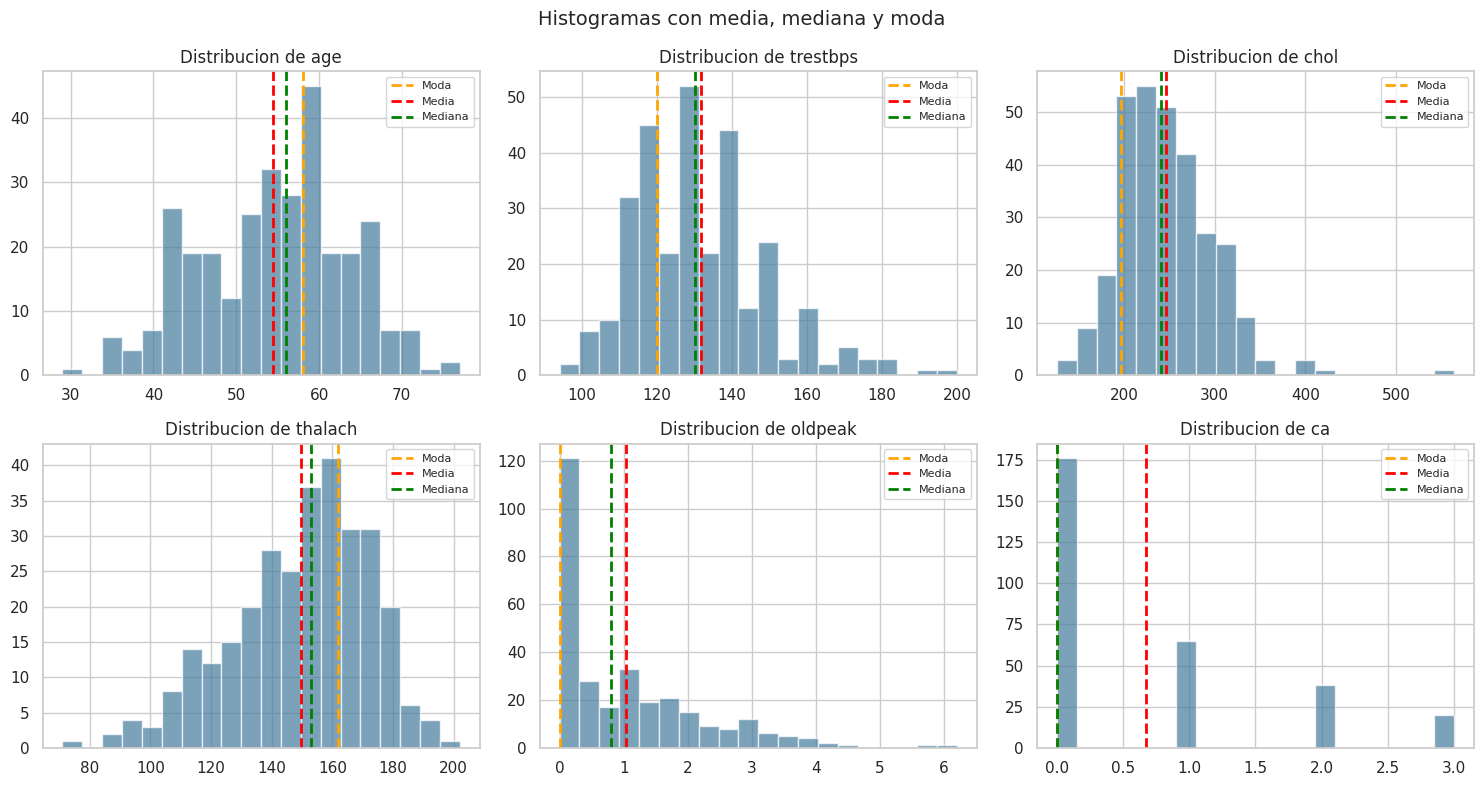

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col], bins=20, alpha=0.7, color='#457b9d')
    axes[i].axvline(df[col].mode()[0], color='orange', ls='--', lw=2, label='Moda')
    axes[i].axvline(df[col].mean(), color='red', ls='--', lw=2, label='Media')
    axes[i].axvline(df[col].median(), color='green', ls='--', lw=2, label='Mediana')
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].legend(fontsize=8)

plt.suptitle('Histogramas con media, mediana y moda', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 KDE (Kernel Density Estimation)

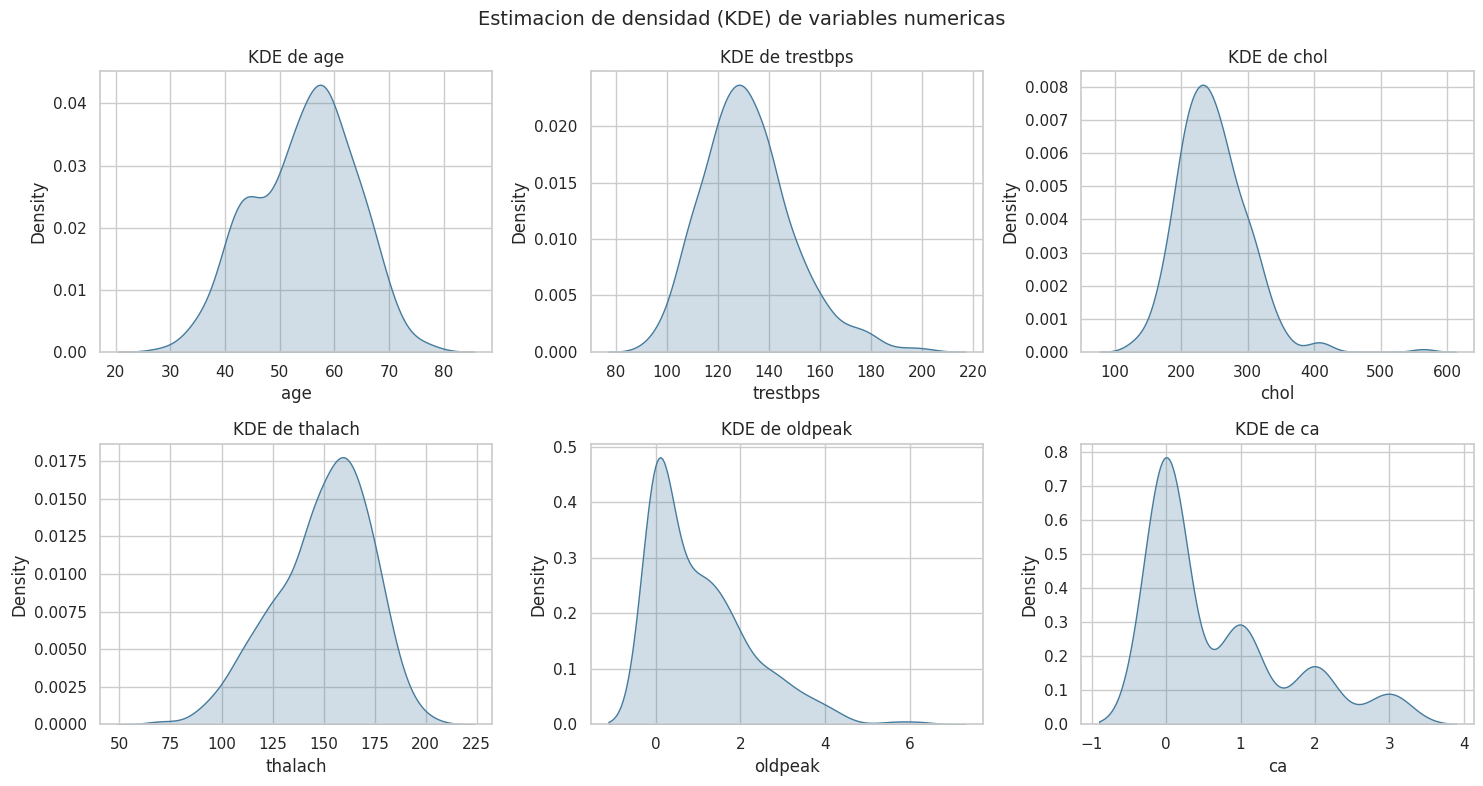

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i], color='#457b9d')
    axes[i].set_title(f'KDE de {col}')

plt.suptitle('Estimacion de densidad (KDE) de variables numericas', fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Boxplots con cuartiles y deteccion de outliers

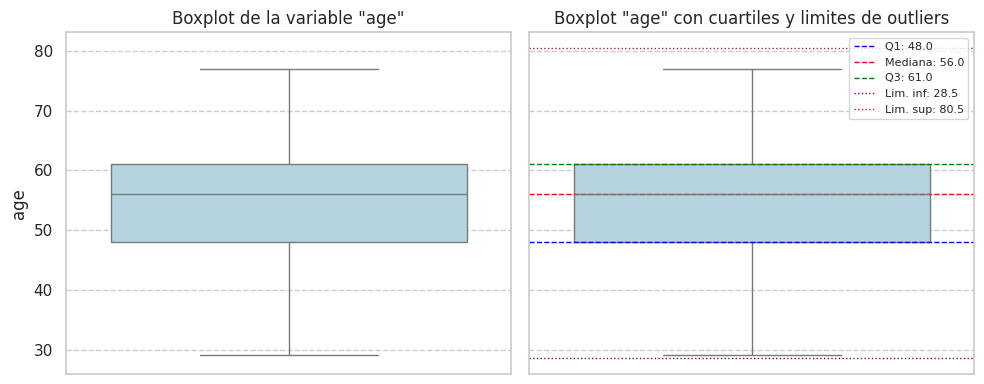

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

age = df['age'].dropna()
age_Q1, age_Q2, age_Q3 = cuartiles(df['age'])
age_IQR = age_Q3 - age_Q1
lower_limit = age_Q1 - 1.5 * age_IQR
upper_limit = age_Q3 + 1.5 * age_IQR

sns.boxplot(data=df, y='age', color='lightblue', ax=ax[0])
ax[0].set_title('Boxplot de la variable "age"')
ax[0].grid(axis='y', ls='--')

sns.boxplot(data=df, y='age', color='lightblue', ax=ax[1])
ax[1].axhline(age_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1: {age_Q1:.1f}')
ax[1].axhline(age_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana: {age_Q2:.1f}')
ax[1].axhline(age_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3: {age_Q3:.1f}')
ax[1].axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lim. inf: {lower_limit:.1f}')
ax[1].axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lim. sup: {upper_limit:.1f}')
ax[1].set_title('Boxplot "age" con cuartiles y limites de outliers')
ax[1].legend(fontsize=8)
ax[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

### 3.6 Violinplots

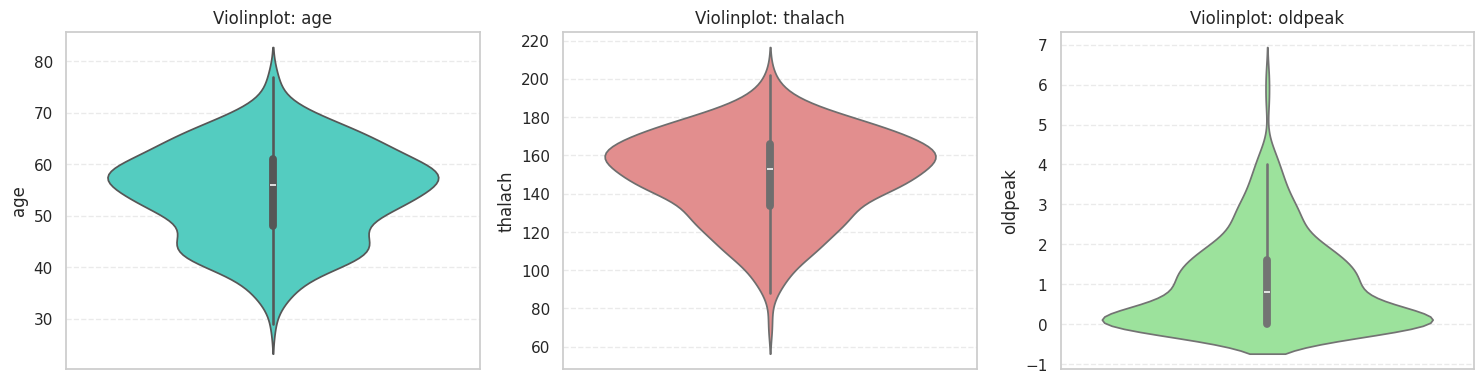

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.violinplot(data=df, y='age', color='turquoise', inner='box', ax=axes[0])
axes[0].set_title('Violinplot: age')
axes[0].grid(axis='y', ls='--', alpha=0.4)

sns.violinplot(data=df, y='thalach', color='lightcoral', inner='box', ax=axes[1])
axes[1].set_title('Violinplot: thalach')
axes[1].grid(axis='y', ls='--', alpha=0.4)

sns.violinplot(data=df, y='oldpeak', color='lightgreen', inner='box', ax=axes[2])
axes[2].set_title('Violinplot: oldpeak')
axes[2].grid(axis='y', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 3.7 Estadistica descriptiva de variables categoricas

#### Frecuencias absolutas y relativas

In [19]:
for col in cat_nominales:
    print_categorias(df, col)

Cantidad de categorias que tiene la variable 'sex': 2

Nombres de categorias presentes en la variable 'sex': [1. 0.]

Frecuencias de cada categoria en la variable 'sex':
     Frecuencia absoluta  Frecuencia relativa (%)
sex                                              
1.0                  206                    67.99
0.0                   97                    32.01

Cantidad de categorias que tiene la variable 'cp': 4

Nombres de categorias presentes en la variable 'cp': [1. 4. 3. 2.]

Frecuencias de cada categoria en la variable 'cp':
     Frecuencia absoluta  Frecuencia relativa (%)
cp                                               
4.0                  144                    47.52
3.0                   86                    28.38
2.0                   50                    16.50
1.0                   23                     7.59

Cantidad de categorias que tiene la variable 'fbs': 2

Nombres de categorias presentes en la variable 'fbs': [1. 0.]

Frecuencias de cada categoria en la v

In [20]:
print_categorias(df, 'target')

Cantidad de categorias que tiene la variable 'target': 2

Nombres de categorias presentes en la variable 'target': ['Sin enfermedad' 'Con enfermedad']

Frecuencias de cada categoria en la variable 'target':
                Frecuencia absoluta  Frecuencia relativa (%)
target                                                      
Sin enfermedad                  164                    54.13
Con enfermedad                  139                    45.87



In [21]:
df[categorical_cols + ['target']].describe()

,sex,cp,fbs,restecg,exang,slope,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,301.000000
mean,0.679868,3.158416,0.148515,0.990099,0.326733,1.600660,4.734219
std,0.467299,0.960126,0.356198,0.994971,0.469794,0.616226,1.939706
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.000000
25%,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000
50%,1.000000,3.000000,0.000000,1.000000,0.000000,2.000000,3.000000
75%,1.000000,4.000000,0.000000,2.000000,1.000000,2.000000,7.000000
max,1.000000,4.000000,1.000000,2.000000,1.000000,3.000000,7.000000


#### Graficos de torta (pie charts)

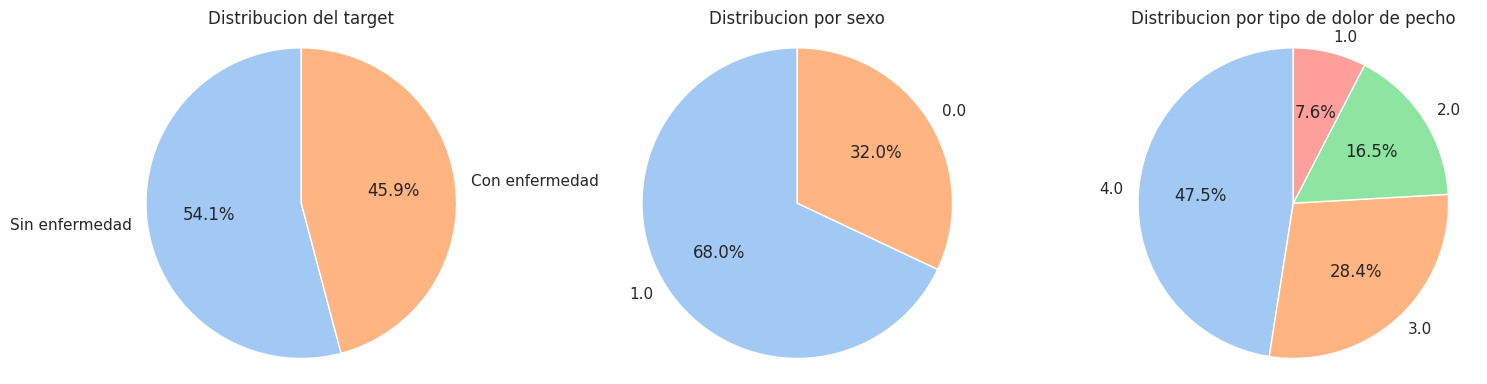

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pie(df, 'target', ax=axes[0], title='Distribucion del target')
plot_pie(df, 'sex', ax=axes[1], title='Distribucion por sexo')
plot_pie(df, 'cp', ax=axes[2], title='Distribucion por tipo de dolor de pecho')

plt.tight_layout()
plt.show()

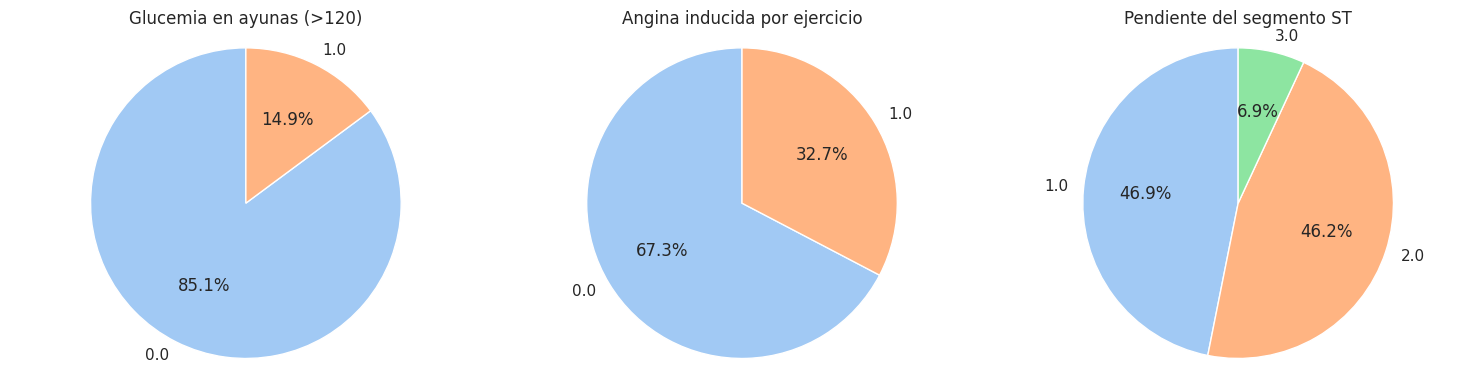

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pie(df, 'fbs', ax=axes[0], title='Glucemia en ayunas (>120)')
plot_pie(df, 'exang', ax=axes[1], title='Angina inducida por ejercicio')
plot_pie(df, 'slope', ax=axes[2], title='Pendiente del segmento ST')

plt.tight_layout()
plt.show()

#### Frecuencias relativas (barras horizontales)

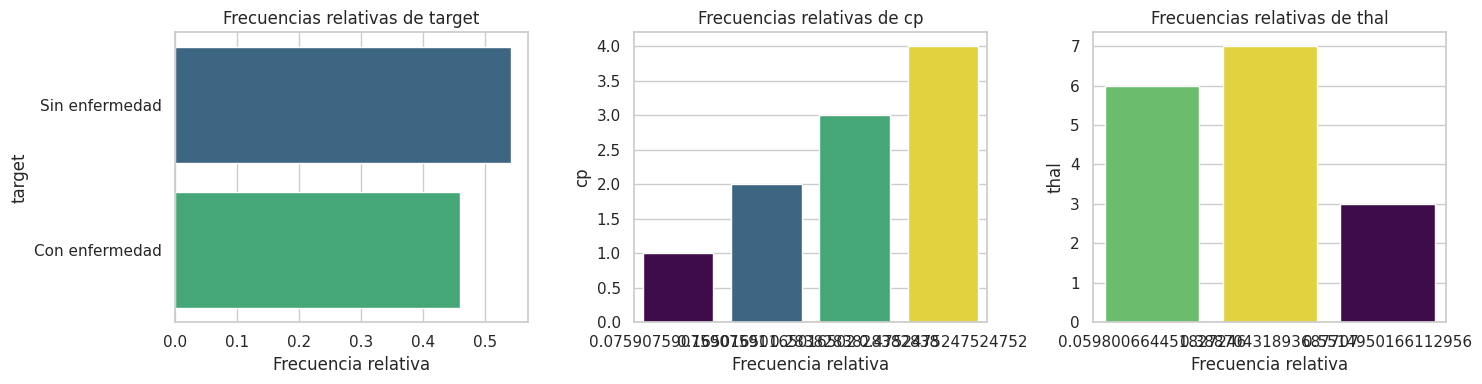

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['target', 'cp', 'thal']):
    freq_rel = df[col].value_counts(normalize=True)
    sns.barplot(x=freq_rel.values, y=freq_rel.index, hue=freq_rel.index, 
                palette='viridis', ax=axes[i], legend=False)
    axes[i].set_title(f'Frecuencias relativas de {col}')
    axes[i].set_xlabel('Frecuencia relativa')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 4. Relaciones entre variables

Con este dataset, la variable objetivo permite ver como cambian algunas mediciones entre personas con y sin enfermedad cardiaca.

In [25]:
resumen_objetivo = df.groupby("target")[["age", "trestbps", "chol", "thalach", "oldpeak"]].mean().round(2)

print("Promedios por grupo objetivo:")
resumen_objetivo

Promedios por grupo objetivo:


,age,trestbps,chol,thalach,oldpeak
target,,,,,
Con enfermedad,56.63,134.57,251.47,139.26,1.57
Sin enfermedad,52.59,129.25,242.64,158.38,0.59


### 4.1 Matriz de correlacion

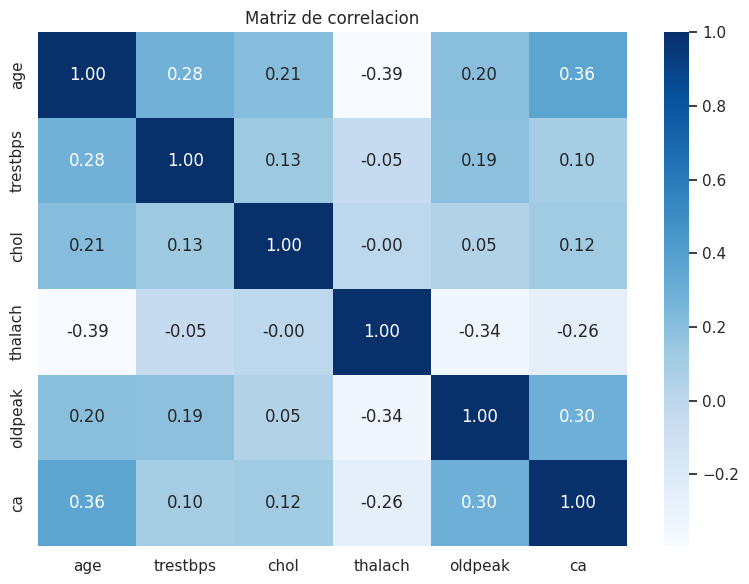

In [26]:
numeric_cols_corr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
corr = df[numeric_cols_corr].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()

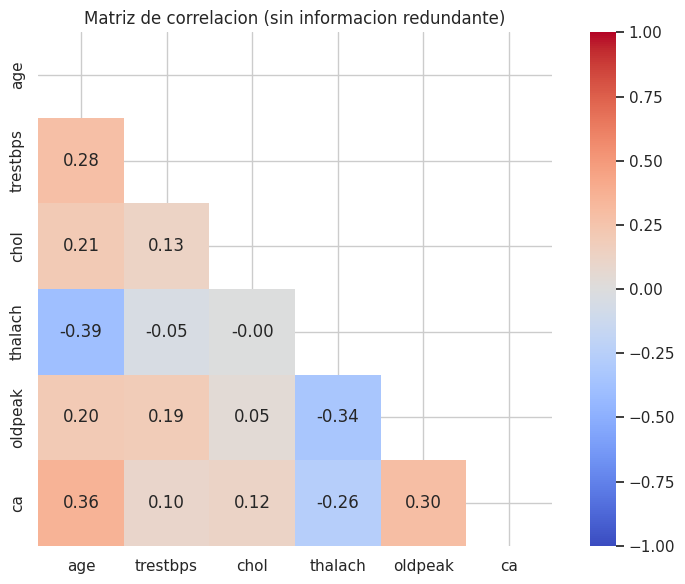

In [27]:
mascara = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara)
plt.title('Matriz de correlacion (sin informacion redundante)')
plt.tight_layout()
plt.show()

### 4.2 Relaciones numerica-numerica

#### Pairplot

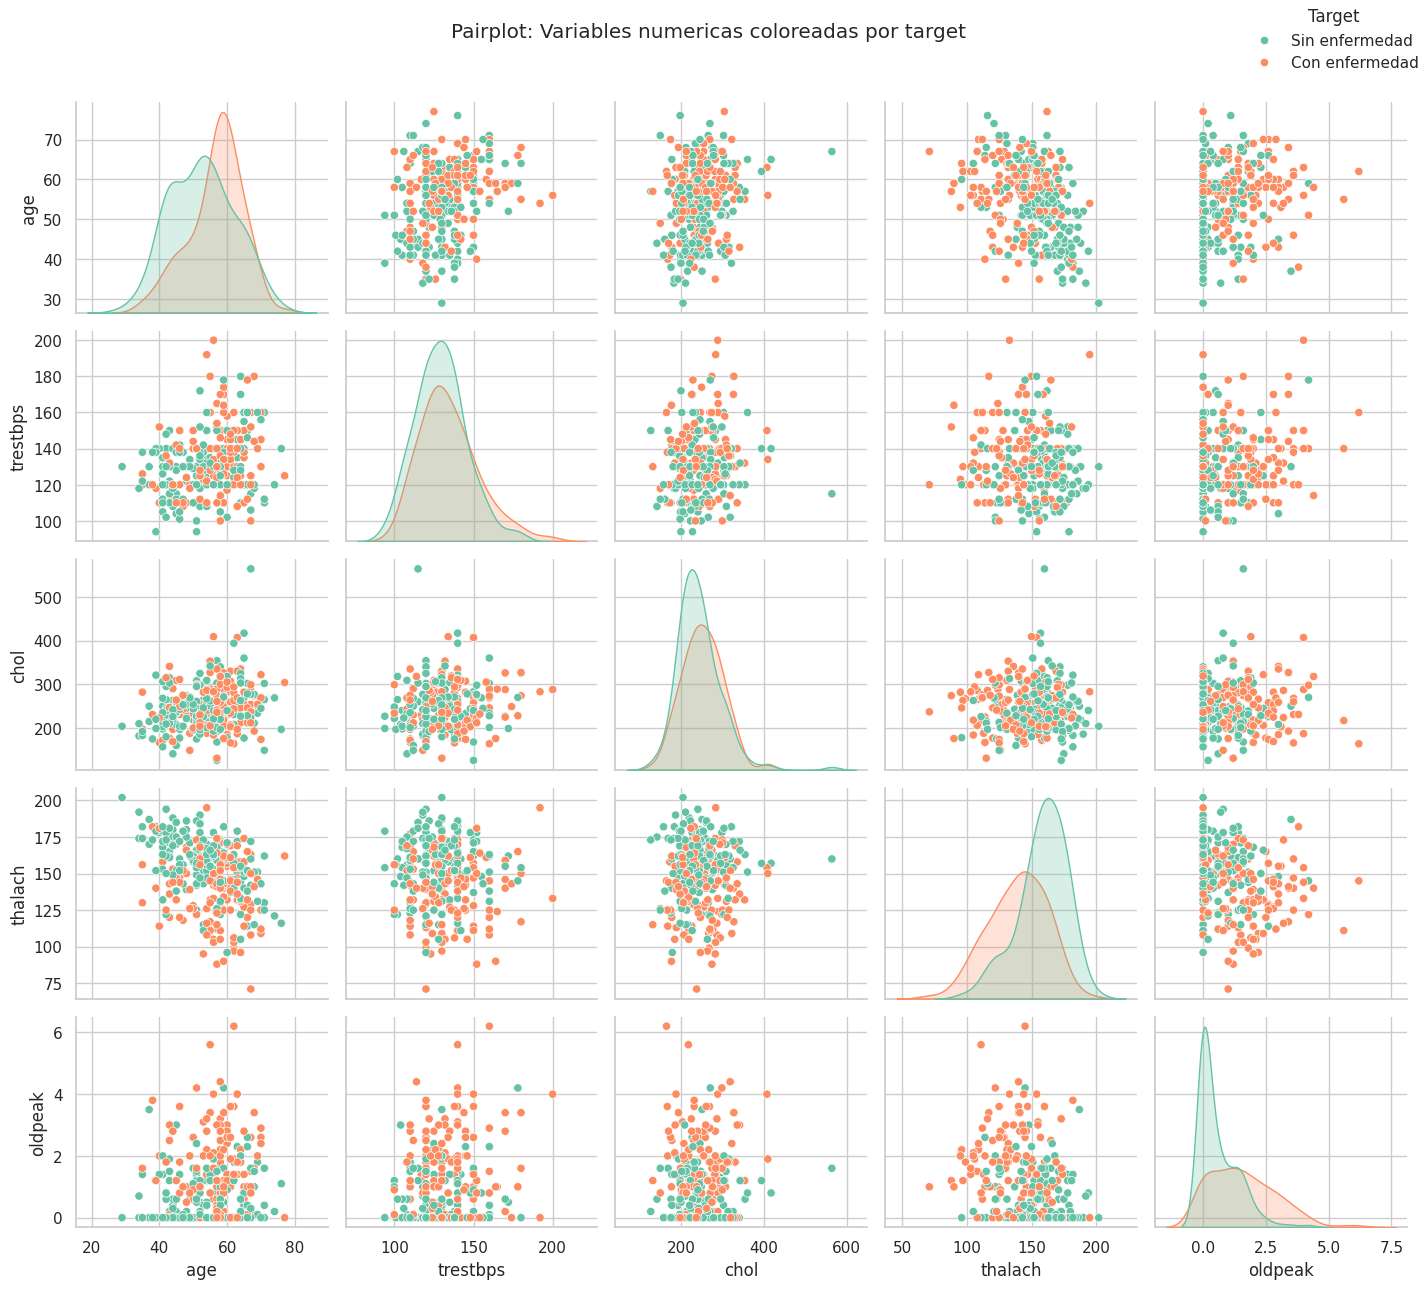

In [28]:
grafico = sns.pairplot(data=df, hue='target', palette='Set2', 
                       vars=['age', 'trestbps', 'chol', 'thalach', 'oldpeak'])
grafico.figure.suptitle('Pairplot: Variables numericas coloreadas por target', y=1.02)
grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Target')
plt.tight_layout()
plt.show()

### 4.3 Relaciones categorica-categorica

#### Tabla de contingencia: sexo vs target

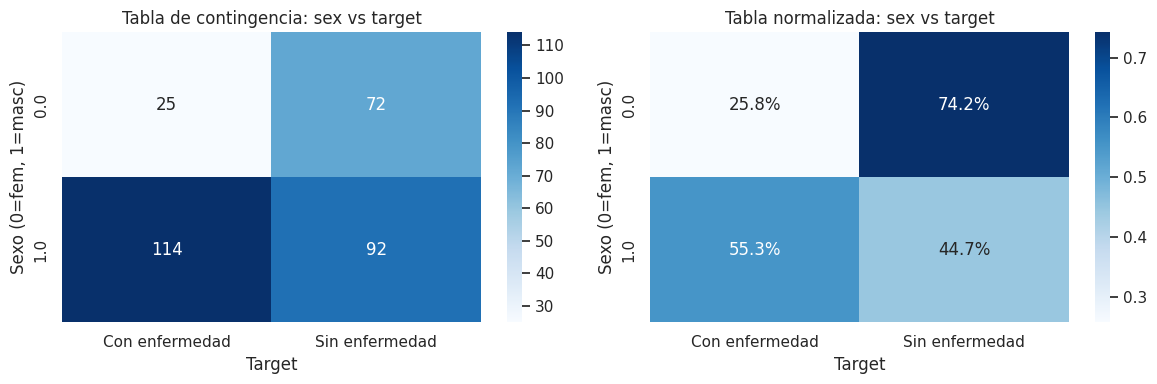

In [29]:
cross_tab = pd.crosstab(df['sex'], df['target'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Tabla de contingencia: sex vs target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Sexo (0=fem, 1=masc)')

cross_tab_pct = pd.crosstab(df['sex'], df['target'], normalize='index')
sns.heatmap(cross_tab_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_title('Tabla normalizada: sex vs target')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Sexo (0=fem, 1=masc)')

plt.tight_layout()
plt.show()

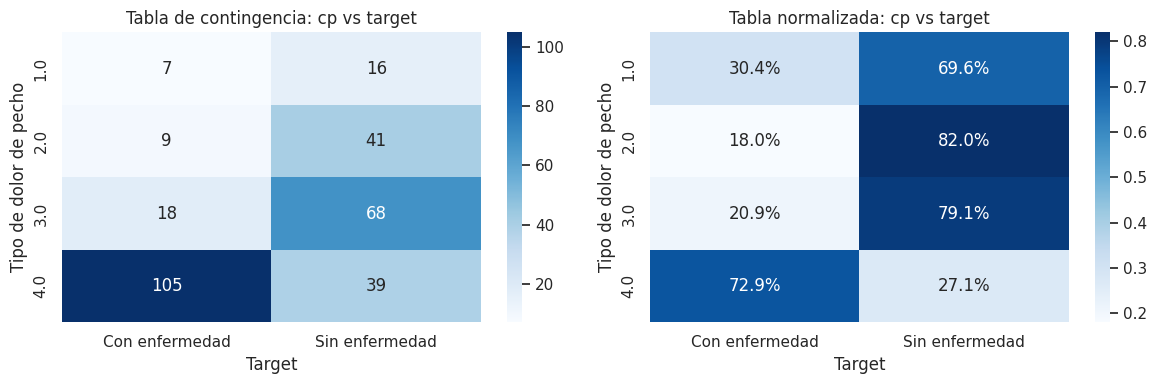

In [30]:
cross_tab2 = pd.crosstab(df['cp'], df['target'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cross_tab2, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Tabla de contingencia: cp vs target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Tipo de dolor de pecho')

cross_tab2_pct = pd.crosstab(df['cp'], df['target'], normalize='index')
sns.heatmap(cross_tab2_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_title('Tabla normalizada: cp vs target')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Tipo de dolor de pecho')

plt.tight_layout()
plt.show()

### 4.4 Relaciones numerica-categorica

#### Boxplots y violinplots: variables numericas vs target

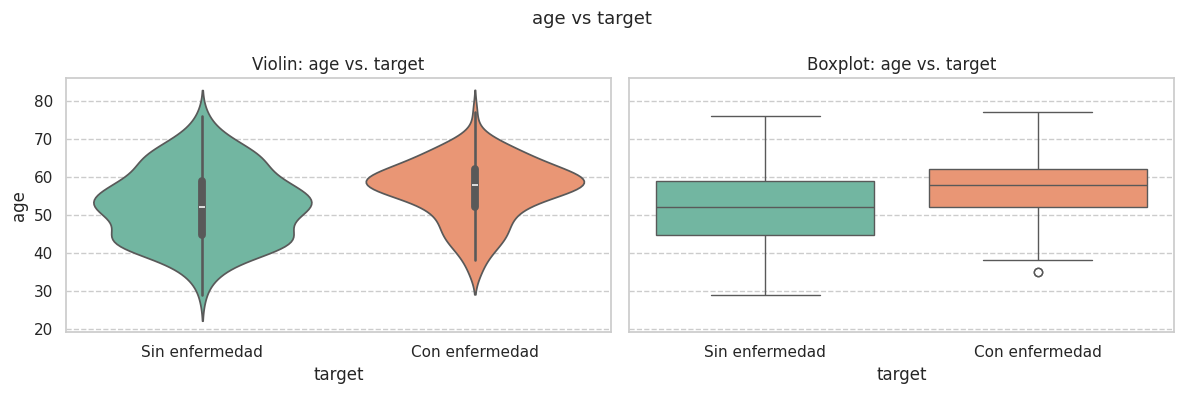

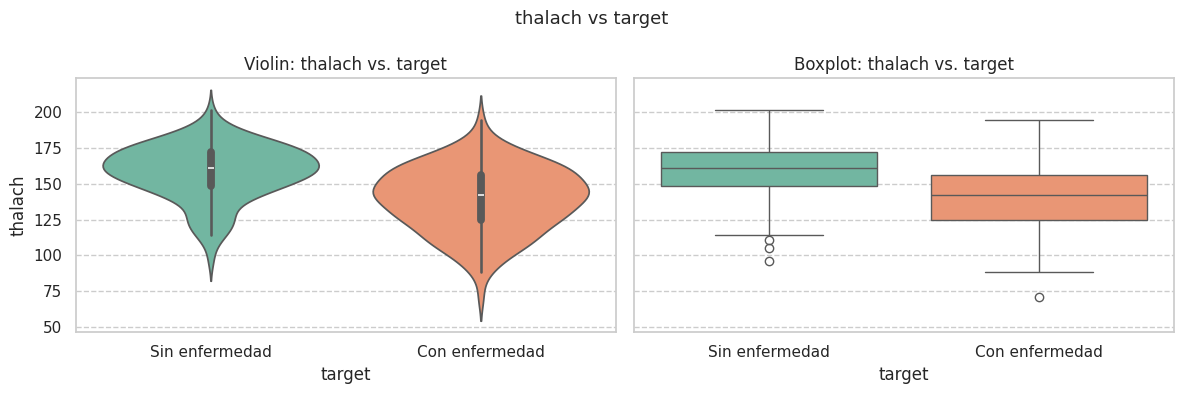

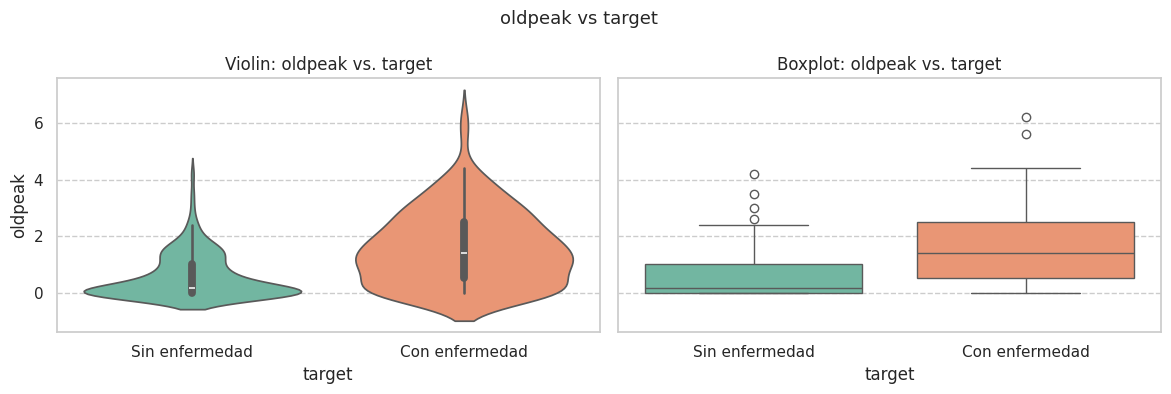

In [31]:
for num in ['age', 'thalach', 'oldpeak']:
    plot_violin_box(df, num, 'target', palette='Set2')

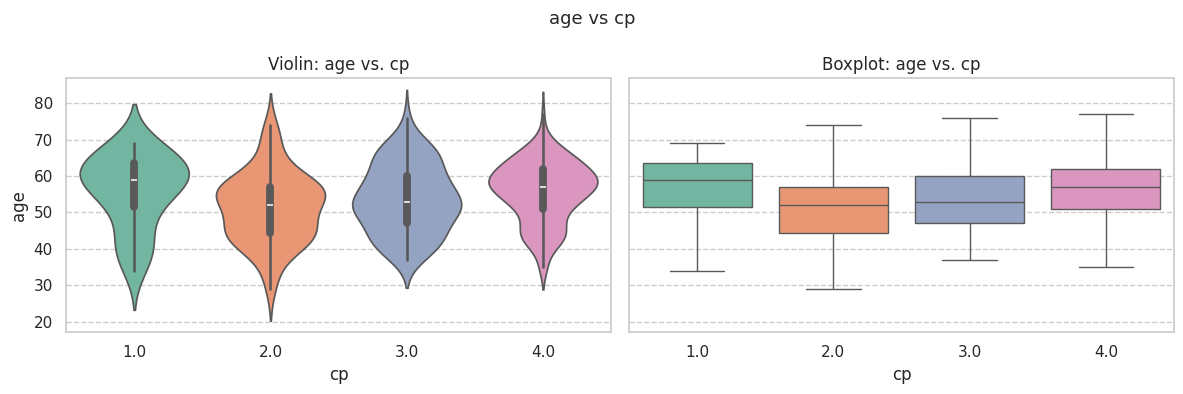

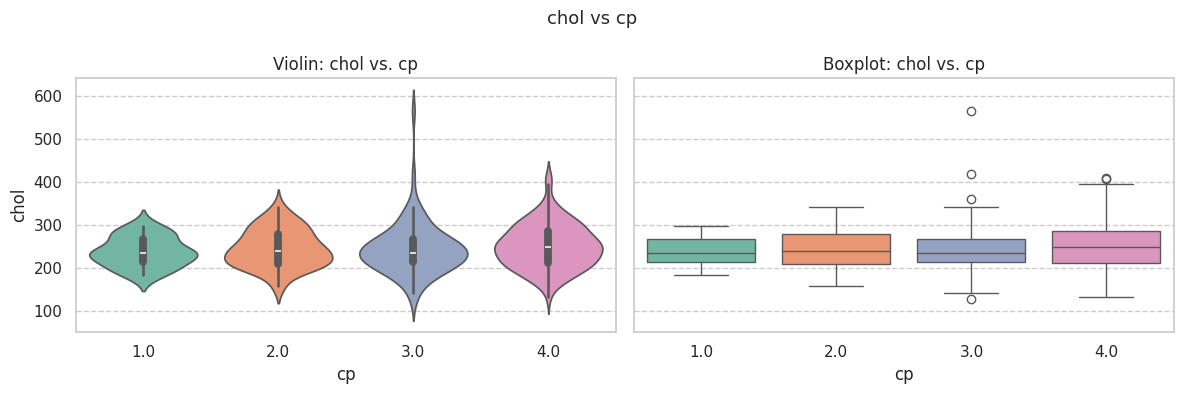

In [32]:
for num in ['age', 'chol']:
    plot_violin_box(df, num, 'cp', palette='Set2')

#### Stripplot y Swarmplot

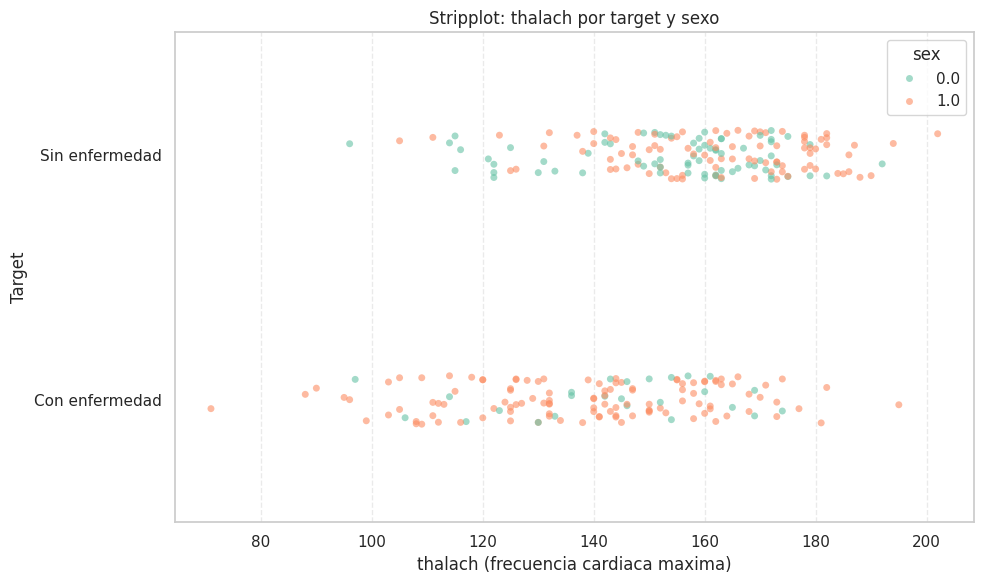

In [33]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='thalach', y='target', 
              hue='sex', palette='Set2', alpha=0.6, size=5, jitter=True)
plt.title('Stripplot: thalach por target y sexo')
plt.xlabel('thalach (frecuencia cardiaca maxima)')
plt.ylabel('Target')
plt.grid(axis='x', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Graficos adicionales

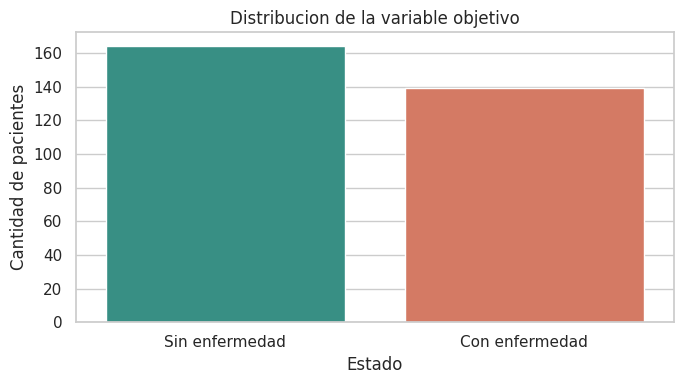

In [34]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="target", hue="target", palette=["#2a9d8f", "#e76f51"], legend=False)
plt.title("Distribucion de la variable objetivo")
plt.xlabel("Estado")
plt.ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

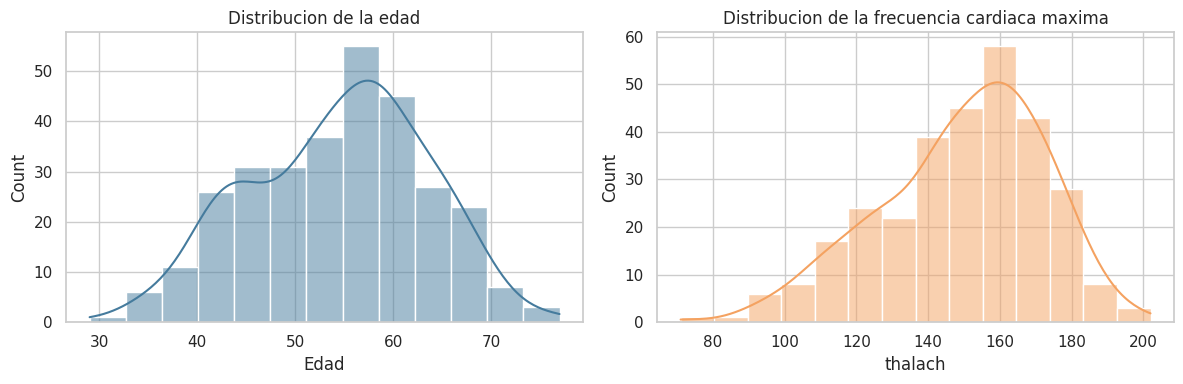

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"], kde=True, ax=axes[0], color="#457b9d")
axes[0].set_title("Distribucion de la edad")
axes[0].set_xlabel("Edad")

sns.histplot(df["thalach"], kde=True, ax=axes[1], color="#f4a261")
axes[1].set_title("Distribucion de la frecuencia cardiaca maxima")
axes[1].set_xlabel("thalach")

plt.tight_layout()
plt.show()

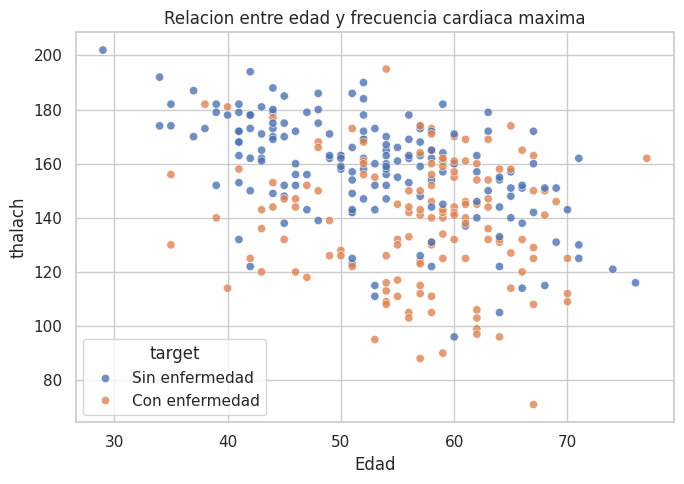

In [36]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="thalach", hue="target", alpha=0.8)
plt.title("Relacion entre edad y frecuencia cardiaca maxima")
plt.xlabel("Edad")
plt.ylabel("thalach")
plt.tight_layout()
plt.show()

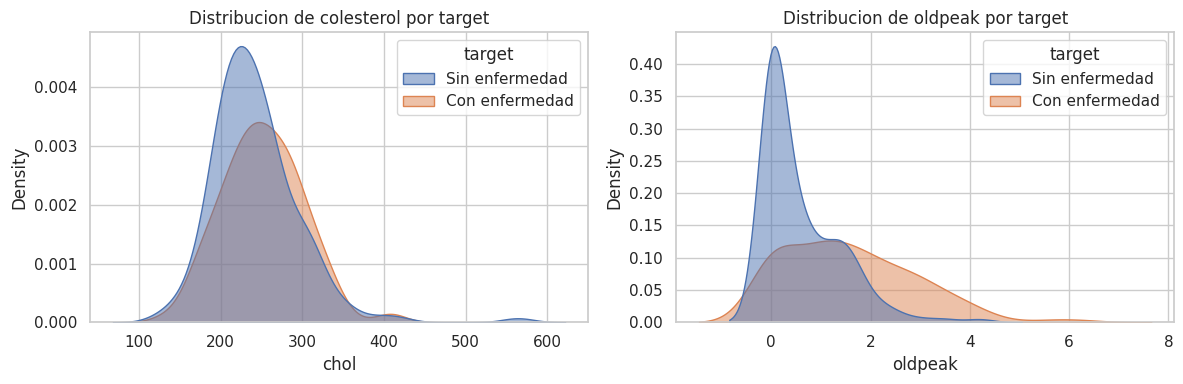

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=df, x='chol', hue='target', fill=True, ax=axes[0], alpha=0.5)
axes[0].set_title('Distribucion de colesterol por target')

sns.kdeplot(data=df, x='oldpeak', hue='target', fill=True, ax=axes[1], alpha=0.5)
axes[1].set_title('Distribucion de oldpeak por target')

plt.tight_layout()
plt.show()

## Conclusion

El dataset Heart Disease de Cleveland tiene variables clinicas utiles para explorar diferencias entre pacientes con y sin enfermedad cardiaca. No es un dataset grande (303 filas), asi que se puede trabajar completo sin tomar muestra.

En este EDA se revisaron:
- **Estadistica descriptiva**: media, mediana, moda, varianza, desviacion estandar, cuartiles, IQR, asimetria y curtosis para las variables numericas; frecuencias absolutas y relativas para las categoricas.
- **Tipos de variables**: se identificaron 6 variables numericas continuas y 7 categoricas nominales.
- **Relaciones entre variables**: se exploraron correlaciones entre numericas (heatmap), relaciones numerica-numerica (pairplot), categorica-categorica (tablas de contingencia) y numerica-categorica (violinplots, boxplots, stripplots).
- **Graficos**: se incluyeron mas de 10 visualizaciones (histogramas, KDE, boxplots, violinplots, pie charts, pairplot, heatmaps, stripplots), superando las 3 minimas requeridas.